<a href="https://colab.research.google.com/github/Mikaelxf/CONSULTA-DE-DADOS-COM-PANDAS/blob/main/analise_faturamento_pista.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# PROJETO: ANÁLISE DE FATURAMENTO - PISTA DE ABASTECIMENTO
# OBJETIVO: Automatizar o cálculo de faturamento e analisar a performance
#           por tipo de combustível e por turno operacional.
# ==============================================================================

# 1. IMPORTAÇÃO DAS BIBLIOTECAS
import pandas as pd               # Utilizada para manipulação e estruturação de tabelas
import matplotlib.pyplot as plt   # Utilizada para a criação dos gráficos visuais

In [14]:
# Simulando a extração de dados do sistema de fechamento das bombas
dados_pista = {
    'Turno': ['Manhã', 'Manhã', 'Manhã', 'Manhã', 'Tarde', 'Tarde', 'Tarde', 'Tarde'],
    'Combustivel': ['Gasolina', 'Aditivada', 'Etanol', 'Diesel', 'Gasolina', 'Aditivada', 'Etanol', 'Diesel'],
    'Litros_Vendidos': [1500, 450, 800, 2100, 1800, 600, 950, 1600],
    'Preco_Litro': [5.89, 6.09, 4.29, 5.79, 5.89, 6.09, 4.29, 5.79]
}

# Convertendo o dicionário bruto em um DataFrame (Tabela estruturada do Pandas)
df_pista = pd.DataFrame(dados_pista)

In [15]:
# ==============================================================================
# FASE 2: ENGENHARIA DE RECURSOS (CÁLCULO AUTOMÁTICO)
# ==============================================================================

# Criando a coluna de faturamento financeiro (Volume x Preço)
df_pista['Faturamento_R$'] = df_pista['Litros_Vendidos'] * df_pista['Preco_Litro']

print("--- BASE DE DADOS CONSOLIDADA ---")
display(df_pista)

--- BASE DE DADOS CONSOLIDADA ---


,Turno,Combustivel,Litros_Vendidos,Preco_Litro,Faturamento_R$
0,Manhã,Gasolina,1500,5.89,8835.0
1,Manhã,Aditivada,450,6.09,2740.5
2,Manhã,Etanol,800,4.29,3432.0
3,Manhã,Diesel,2100,5.79,12159.0
4,Tarde,Gasolina,1800,5.89,10602.0
5,Tarde,Aditivada,600,6.09,3654.0
6,Tarde,Etanol,950,4.29,4075.5
7,Tarde,Diesel,1600,5.79,9264.0


In [4]:
# ==============================================================================
# FASE 3: ANÁLISE DE PERFORMANCE POR PRODUTO (COMBUSTÍVEL)
# ==============================================================================

# Agrupando os dados para descobrir qual combustível gerou mais receita total
resumo_combustivel = df_pista.groupby('Combustivel')['Faturamento_R$'].sum().reset_index()

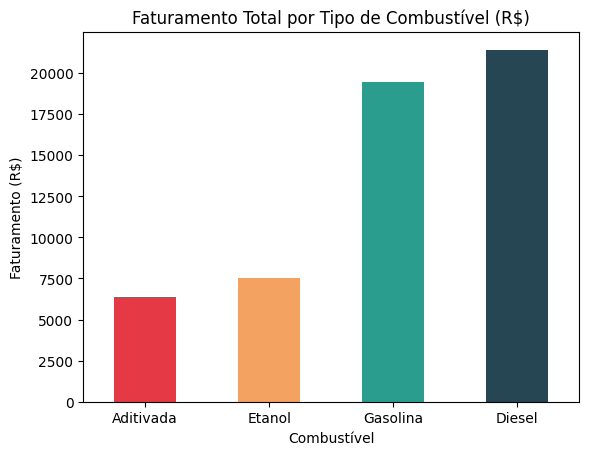

In [16]:
# Gerando o gráfico de barras para o faturamento por combustível
resumo_combustivel.plot(kind='bar', x='Combustivel', y='Faturamento_R$', color=['#e63946', '#f4a261', '#2a9d8f', '#264653'], legend=False)

# Configurando as legendas e títulos do gráfico
plt.title('Faturamento Total por Tipo de Combustível (R$)')
plt.ylabel('Faturamento (R$)')
plt.xlabel('Combustível')
plt.xticks(rotation=0) # Mantém os nomes dos combustíveis na horizontal
plt.show()

In [17]:
# ==============================================================================
# FASE 4: ANÁLISE DE PERFORMANCE OPERACIONAL (TURNO)
# ==============================================================================

# Agrupando os dados para comparar o desempenho financeiro entre as equipes (Manhã x Tarde)
resumo_turno = df_pista.groupby('Turno')['Faturamento_R$'].sum().reset_index()

print("--- TABELA: RESULTADO POR TURNO ---")
display(resumo_turno)

--- TABELA: RESULTADO POR TURNO ---


,Turno,Faturamento_R$
0,Manhã,27166.5
1,Tarde,27595.5


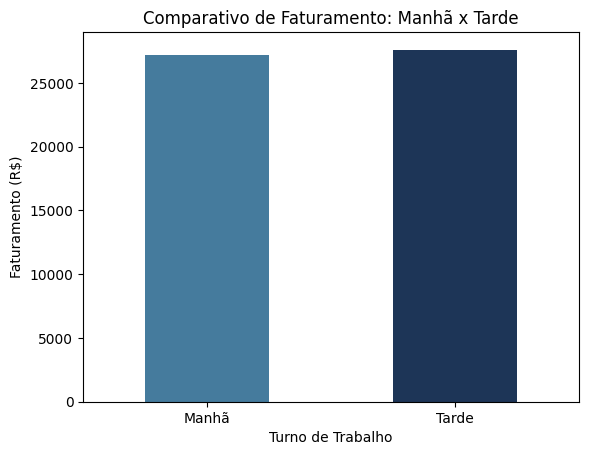

In [13]:
# Gerando o gráfico de barras comparativo entre os turnos
resumo_turno.plot(kind='bar', x='Turno', y='Faturamento_R$', color=['#457b9d', '#1d3557'], legend=False)

# Configurando as legendas e títulos do gráfico
plt.title('Comparativo de Faturamento: Manhã x Tarde')
plt.ylabel('Faturamento (R$)')
plt.xlabel('Turno de Trabalho')
plt.xticks(rotation=0)

plt.show()